# 03 — Modelo NCF Híbrido
Entrenamiento de Neural Collaborative Filtering con features de contenido (tags TF-IDF)

In [1]:
# ── SETUP COLAB ──────────────────────────────────────────────
!git clone https://github.com/miguel-anay/music-recommender-ncf.git 2>/dev/null || echo "repo ya clonado"
!pip install -q "numpy<2" pandas matplotlib scikit-learn torch

import os, sys
from pathlib import Path
if not Path("/content/lastfm").exists():
    !pip install -q gdown
    !gdown --folder https://drive.google.com/drive/folders/1BfvqaOTlvb7EKtp8HuqgBReQ8PcUaUVe -O /content/lastfm --quiet
else:
    print("Datos ya disponibles en /content/lastfm")

sys.path.append("/content/music-recommender-ncf/src")
import os; os.makedirs("/content/music-recommender-ncf/results", exist_ok=True)
print("Setup completo")


repo ya clonado
Datos ya disponibles en /content/lastfm
Setup completo


In [2]:
import sys
sys.path.append('../src')

import torch
import numpy as np
import matplotlib.pyplot as plt

from dataset import load_and_filter, binarize, build_tag_features, split_by_user, LastFMDataset
from model import NCFHybrid
from train import train
from config import EMBED_DIM, EPOCHS, BATCH_SIZE, LEARNING_RATE, NEG_RATIO

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

Dispositivo: cpu


## Preparar datos (reproducir pipeline de notebook 02)

In [3]:
df = binarize(load_and_filter())

user_ids      = sorted(df['userID'].unique())
artist_ids    = sorted(df['artistID'].unique())
user_to_idx   = {u: i for i, u in enumerate(user_ids)}
artist_to_idx = {a: i for i, a in enumerate(artist_ids)}

tag_matrix, _ = build_tag_features(artist_ids)
train_df, test_df = split_by_user(df)

train_dataset = LastFMDataset(train_df, tag_matrix, user_to_idx, artist_to_idx, neg_ratio=NEG_RATIO)

n_users   = len(user_ids)
n_artists = len(artist_ids)
print(f'Usuarios: {n_users} | Artistas: {n_artists} | Pares entrenamiento: {len(train_dataset):,}')

Usuarios: 1874 | Artistas: 2828 | Pares entrenamiento: 145,580


## Arquitectura del modelo

In [4]:
model = NCFHybrid(n_users=n_users, n_artists=n_artists,
                  embed_dim=EMBED_DIM).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParámetros entrenables: {total_params:,}')

NCFHybrid(
  (user_embedding): Embedding(1874, 64)
  (artist_embedding): Embedding(2828, 64)
  (tag_projection): Linear(in_features=50, out_features=64, bias=False)
  (mlp): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Parámetros entrenables: 337,153


## Entrenamiento

In [5]:
history = train(model, train_dataset,
                epochs=EPOCHS, lr=LEARNING_RATE,
                batch_size=BATCH_SIZE, device=device)

Epoch 01/20  Loss: 0.4132
Epoch 02/20  Loss: 0.3332
Epoch 03/20  Loss: 0.2978
Epoch 04/20  Loss: 0.2750
Epoch 05/20  Loss: 0.2551
Epoch 06/20  Loss: 0.2373
Epoch 07/20  Loss: 0.2214
Epoch 08/20  Loss: 0.2051
Epoch 09/20  Loss: 0.1899
Epoch 10/20  Loss: 0.1741
Epoch 11/20  Loss: 0.1602
Epoch 12/20  Loss: 0.1475
Epoch 13/20  Loss: 0.1347
Epoch 14/20  Loss: 0.1248
Epoch 15/20  Loss: 0.1158
Epoch 16/20  Loss: 0.1074
Epoch 17/20  Loss: 0.0991
Epoch 18/20  Loss: 0.0922
Epoch 19/20  Loss: 0.0867
Epoch 20/20  Loss: 0.0813

Mejor loss: 0.0813  →  guardado en results/best_model.pt


## Curva de pérdida

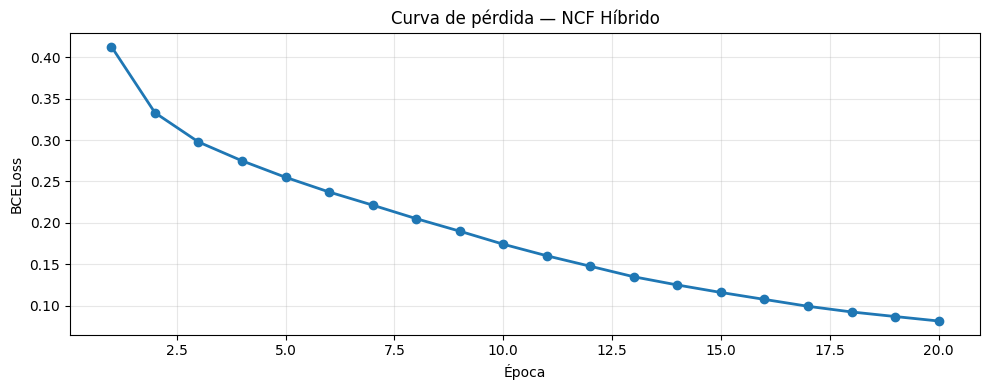

Loss inicial: 0.4132
Loss final:   0.0813
Reducción:    80.3%


In [6]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(history)+1), history, marker='o', linewidth=2)
plt.xlabel('Época')
plt.ylabel('BCELoss')
plt.title('Curva de pérdida — NCF Híbrido')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Loss inicial: {history[0]:.4f}')
print(f'Loss final:   {history[-1]:.4f}')
print(f'Reducción:    {(history[0]-history[-1])/history[0]*100:.1f}%')

## Predicciones de ejemplo

In [7]:
model.eval()
sample_user = user_ids[0]
sample_u_idx = user_to_idx[sample_user]

# Predecir para los primeros 10 artistas
sample_artists = artist_ids[:10]
with torch.no_grad():
    u = torch.tensor([sample_u_idx] * 10, dtype=torch.long).to(device)
    a = torch.tensor([artist_to_idx[a] for a in sample_artists], dtype=torch.long).to(device)
    t = torch.tensor(tag_matrix[[artist_to_idx[a] for a in sample_artists]], dtype=torch.float32).to(device)
    scores = model(u, a, t).cpu().numpy()

print(f'Scores para usuario {sample_user} (primeros 10 artistas):')
for artist_id, score in sorted(zip(sample_artists, scores), key=lambda x: -x[1]):
    print(f'  Artista {artist_id}: {score:.4f}')

Scores para usuario 2 (primeros 10 artistas):
  Artista 7: 0.3036
  Artista 2: 0.0022
  Artista 9: 0.0003
  Artista 15: 0.0000
  Artista 8: 0.0000
  Artista 11: 0.0000
  Artista 13: 0.0000
  Artista 10: 0.0000
  Artista 6: 0.0000
  Artista 12: 0.0000


## Notas de arquitectura
- **Embeddings**: usuario (64d) + artista (64d) + proyección TF-IDF (50→64d)
- **MLP**: concat(192d) → 128 → 64 → 1 → Sigmoid
- **BCELoss** con 4 negativos aleatorios por positivo
- El mejor modelo se guarda en `results/best_model.pt`